In [1]:
"""
EMG-ICA Correlation Analysis for Muscle Artifact Detection
This script correlates ICA components with EMG channels to automatically
identify muscle-contaminated components in EEG data.
"""

import numpy as np
import mne
from scipy import signal
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import pandas as pd


def compute_muscle_score(psd, freqs, low_freq=20, high_freq=100):
    """
    Compute a muscle artifact score based on spectral characteristics.
    High scores indicate muscle-like activity.
    """
    # Get indices for frequency bands
    low_idx = np.argmin(np.abs(freqs - low_freq))
    high_idx = np.argmin(np.abs(freqs - high_freq))
    alpha_low = np.argmin(np.abs(freqs - 8))
    alpha_high = np.argmin(np.abs(freqs - 12))
    
    # Muscle power (20-100 Hz)
    muscle_power = np.mean(psd[low_idx:high_idx])
    
    # Alpha power (8-12 Hz) - neural activity
    alpha_power = np.mean(psd[alpha_low:alpha_high])
    
    # Muscle score: ratio of high-freq to low-freq
    # Higher ratio = more muscle-like
    score = muscle_power / (alpha_power + 1e-10)
    
    return score


def correlate_ica_with_emg(raw, ica, emg_channel_names, method='pearson', 
                           freq_band=(20, 100), correlation_threshold=0.1,
                           use_spectral_features=True):
    """
    Correlate ICA components with EMG channels to identify muscle artifacts.
    Now includes spectral feature analysis for better identification.
    
    Parameters:
    -----------
    raw : mne.io.Raw
        Raw data object containing both EEG and EMG channels
    ica : mne.preprocessing.ICA
        Fitted ICA object
    emg_channel_names : list
        Names of EMG channels (e.g., ['EMG1', 'EMG2', 'EMG3'])
    method : str
        'pearson' or 'spearman' correlation
    freq_band : tuple
        Frequency band for filtering (default: 20-100 Hz for muscle activity)
    correlation_threshold : float
        Threshold for flagging components (default: 0.1)
    use_spectral_features : bool
        If True, compute combined score using both correlation and spectral features
    
    Returns:
    --------
    results_df : pd.DataFrame
        DataFrame with correlation results for each component
    muscle_components : list
        List of component indices identified as muscle artifacts
    """
    
    # Get ICA sources
    sources = ica.get_sources(raw)
    
    # Extract EMG data
    emg_data = raw.copy().pick_channels(emg_channel_names)
    
    # Optional: Filter both ICA sources and EMG in muscle frequency band
    print(f"Filtering data in {freq_band} Hz band...")
    sources_filtered = sources.copy().filter(l_freq=freq_band[0], h_freq=freq_band[1])
    emg_filtered = emg_data.copy().filter(l_freq=freq_band[0], h_freq=freq_band[1], picks=['EMG1','EMG2','EMG3'])
    
    # Get the data arrays
    ica_data = sources_filtered.get_data()  # shape: (n_components, n_times)
    emg_array = emg_filtered.get_data()     # shape: (n_emg_channels, n_times)
    
    # Calculate RMS (root mean square) for each EMG channel to get envelope
    # This captures muscle activity strength better than raw signal
    emg_rms = []
    window_size = int(raw.info['sfreq'] * 0.05)  # 50ms window
    for emg_ch in range(emg_array.shape[0]):
        rms = np.sqrt(np.convolve(emg_array[emg_ch]**2, 
                                  np.ones(window_size)/window_size, 
                                  mode='same'))
        emg_rms.append(rms)
    emg_rms = np.array(emg_rms)
    
    # Also calculate RMS for ICA components
    ica_rms = []
    for ic in range(ica_data.shape[0]):
        rms = np.sqrt(np.convolve(ica_data[ic]**2, 
                                  np.ones(window_size)/window_size, 
                                  mode='same'))
        ica_rms.append(rms)
    ica_rms = np.array(ica_rms)
    
    # Correlate each ICA component with each EMG channel
    results = []
    
    # Also compute PSD for each component to get spectral features
    print("Computing power spectral density for components...")
    sources = ica.get_sources(raw)
    psd_params = dict(fmin=2, fmax=100, n_fft=2048)
    psds, freqs = sources.compute_psd(**psd_params).get_data(return_freqs=True)
    
    for ic_idx in range(ica.n_components_):
        ic_correlations = []
        
        for emg_idx, emg_name in enumerate(emg_channel_names):
            # Correlate RMS envelopes
            if method == 'pearson':
                corr, pval = pearsonr(ica_rms[ic_idx], emg_rms[emg_idx])
            else:  # spearman
                corr, pval = spearmanr(ica_rms[ic_idx], emg_rms[emg_idx])
            
            ic_correlations.append({
                'emg_channel': emg_name,
                'correlation': corr,
                'abs_correlation': abs(corr),
                'p_value': pval
            })
        
        # Get max correlation across all EMG channels
        max_corr = max(ic_correlations, key=lambda x: x['abs_correlation'])
        
        # Compute spectral muscle score
        muscle_score = compute_muscle_score(psds[ic_idx], freqs) if use_spectral_features else 0
        
        # Compute high-frequency power ratio (20-100 Hz vs 1-20 Hz)
        low_band_idx = (freqs >= 1) & (freqs < 20)
        high_band_idx = (freqs >= 20) & (freqs <= 100)
        low_power = np.mean(psds[ic_idx][low_band_idx])
        high_power = np.mean(psds[ic_idx][high_band_idx])
        hf_ratio = high_power / (low_power + 1e-10)
        
        # Combined score: correlation * spectral features
        if use_spectral_features:
            combined_score = max_corr['abs_correlation'] * np.log10(muscle_score + 1) * hf_ratio
        else:
            combined_score = max_corr['abs_correlation']
        
        results.append({
            'ICA_component': f'ICA{ic_idx:03d}',
            'component_idx': ic_idx,
            'max_correlation': max_corr['correlation'],
            'max_abs_correlation': max_corr['abs_correlation'],
            'best_emg_channel': max_corr['emg_channel'],
            'p_value': max_corr['p_value'],
            'muscle_score': muscle_score,
            'hf_ratio': hf_ratio,
            'combined_score': combined_score,
            'all_correlations': ic_correlations
        })
    
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    # Sort by combined score (if using spectral features) or correlation
    sort_column = 'combined_score' if use_spectral_features else 'max_abs_correlation'
    results_df = results_df.sort_values(sort_column, ascending=False)
    
    # Identify muscle components
    # Use combined score if available, otherwise use correlation threshold
    if use_spectral_features:
        # Threshold for combined score (empirically determined)
        # Components with high combined score are likely muscle
        muscle_threshold = np.percentile(results_df['combined_score'], 75)  # Top 25%
        muscle_components = results_df[
            (results_df['combined_score'] > muscle_threshold) & 
            (results_df['max_abs_correlation'] > correlation_threshold) &
            (results_df['hf_ratio'] > 0.5)  # Must have elevated high-freq power
        ]['component_idx'].tolist()
    else:
        muscle_components = results_df[
            results_df['max_abs_correlation'] > correlation_threshold
        ]['component_idx'].tolist()
    
    print(f"\n{'='*60}")
    print(f"Found {len(muscle_components)} potential muscle components")
    print(f"(using {'combined score + correlation' if use_spectral_features else 'correlation'} threshold)")
    print(f"{'='*60}\n")
    
    return results_df, muscle_components, ica_rms, emg_rms


def plot_emg_correlation_results(results_df, ica, raw, emg_channel_names, 
                                 top_n=10):
    """
    Visualize the top N components most correlated with EMG.
    """
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot 1: Bar plot of correlations
    top_components = results_df.head(top_n)
    
    axes[0].barh(range(len(top_components)), 
                 top_components['max_abs_correlation'].values,
                 color=['red' if x > 0.1 else 'gray' 
                       for x in top_components['max_abs_correlation'].values])
    axes[0].set_yticks(range(len(top_components)))
    axes[0].set_yticklabels(top_components['ICA_component'].values)
    axes[0].set_xlabel('Absolute Correlation with EMG')
    axes[0].set_title(f'Top {top_n} ICA Components Correlated with EMG')
    axes[0].axvline(x=0.1, color='red', linestyle='--', 
                   label='Threshold (0.1)')
    axes[0].legend()
    axes[0].invert_yaxis()
    
    # Plot 2: Heatmap of all correlations
    correlation_matrix = np.zeros((len(results_df), len(emg_channel_names)))
    for i, row in results_df.iterrows():
        for j, corr_info in enumerate(row['all_correlations']):
            correlation_matrix[results_df.index.get_loc(i), j] = \
                corr_info['correlation']
    
    im = axes[1].imshow(correlation_matrix[:top_n], aspect='auto', 
                       cmap='RdBu_r', vmin=-1, vmax=1)
    axes[1].set_yticks(range(top_n))
    axes[1].set_yticklabels(top_components['ICA_component'].values)
    axes[1].set_xticks(range(len(emg_channel_names)))
    axes[1].set_xticklabels(emg_channel_names)
    axes[1].set_title('Correlation Heatmap: ICA Components vs EMG Channels')
    plt.colorbar(im, ax=axes[1], label='Correlation')
    
    plt.tight_layout()
    return fig


def plot_component_emg_comparison(raw, ica, ica_rms, emg_rms, 
                                  component_idx, emg_channel_names,
                                  time_window=(0, 10)):
    """
    Plot a specific ICA component alongside EMG channels for visual inspection.
    """
    
    sources = ica.get_sources(raw)
    
    # Get time indices
    sfreq = raw.info['sfreq']
    start_idx = int(time_window[0] * sfreq)
    end_idx = int(time_window[1] * sfreq)
    times = np.arange(start_idx, end_idx) / sfreq
    
    fig, axes = plt.subplots(len(emg_channel_names) + 2, 1, 
                            figsize=(14, 3 * (len(emg_channel_names) + 2)),
                            sharex=True)
    
    # Plot ICA component
    ic_data = sources.get_data()[component_idx, start_idx:end_idx]
    axes[0].plot(times, ic_data, 'k-', linewidth=0.5)
    axes[0].set_ylabel(f'ICA{component_idx:03d}\n(AU)', fontsize=10)
    axes[0].set_title(f'ICA Component {component_idx:03d} vs EMG Channels', 
                     fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Plot ICA RMS envelope
    axes[1].plot(times, ica_rms[component_idx, start_idx:end_idx], 
                'r-', linewidth=1.5, label='ICA RMS')
    axes[1].set_ylabel('RMS\n(AU)', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    # Plot each EMG channel
    emg_data = raw.copy().pick_channels(emg_channel_names)
    emg_array = emg_data.get_data()[:, start_idx:end_idx]
    
    for i, emg_name in enumerate(emg_channel_names):
        axes[i+2].plot(times, emg_rms[i, start_idx:end_idx], 
                      'b-', linewidth=1.5)
        axes[i+2].set_ylabel(f'{emg_name}\nRMS (µV)', fontsize=10)
        axes[i+2].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time (s)', fontsize=11)
    plt.tight_layout()
    
    return fig


# ============================================================================
# USAGE EXAMPLE
# ============================================================================

if __name__ == "__main__":
    """
    Example usage - adapt this to your data
    """
    
    # Load your data
    # raw = mne.io.read_raw_fif('your_data.fif', preload=True)
    # ica = mne.preprocessing.read_ica('your_ica.fif')
    
    # Define your EMG channel names
    emg_channels = ['EMG1', 'EMG2', 'EMG3']  # REPLACE with your actual names
    
    print("="*60)
    print("EMG-ICA Correlation Analysis")
    print("="*60)
    
    # Run correlation analysis
    # results_df, muscle_comps, ica_rms, emg_rms = correlate_ica_with_emg(
    #     raw=raw,
    #     ica=ica,
    #     emg_channel_names=emg_channels,
    #     method='pearson',  # or 'spearman'
    #     freq_band=(20, 100),  # muscle activity frequency range
    #     correlation_threshold=0.1
    # )
    
    # Display results
    # print("\nTop 10 components correlated with EMG:")
    # print(results_df[['ICA_component', 'max_abs_correlation', 
    #                   'best_emg_channel', 'p_value']].head(10))
    
    # Plot overview
    # fig1 = plot_emg_correlation_results(results_df, ica, raw, 
    #                                     emg_channels, top_n=15)
    # plt.savefig('emg_ica_correlations.png', dpi=150, bbox_inches='tight')
    
    # Inspect specific components
    # for comp_idx in muscle_comps[:3]:  # Top 3 muscle components
    #     fig = plot_component_emg_comparison(
    #         raw, ica, ica_rms, emg_rms, comp_idx, 
    #         emg_channels, time_window=(10, 20)
    #     )
    #     plt.savefig(f'component_ICA{comp_idx:03d}_vs_EMG.png', 
    #                dpi=150, bbox_inches='tight')
    
    # plt.show()
    
    # Export results to CSV
    # results_df.to_csv('ica_emg_correlations.csv', index=False)
    
    # Mark components for exclusion in ICA
    # ica.exclude = muscle_comps
    # print(f"\nMarked {len(muscle_comps)} components for exclusion")
    # ica.save('ica_with_muscle_exclusions.fif', overwrite=True)
    
    print("\n" + "="*60)
    print("Analysis complete!")
    print("="*60)

EMG-ICA Correlation Analysis

Analysis complete!


In [2]:

# TODO: Update these to match your EMG channel names
EMG_CHANNELS = ['EMG1', 'EMG2', 'EMG3']

# ICA parameters
N_COMPONENTS = None  # None = use all available components (recommended)
                     # Or specify a number, e.g., 20, 30, etc.
ICA_METHOD = 'infomax'  # 'infomax', 'fastica', or 'picard'
ICA_FIT_PARAMS = {'extended': True}  # Extended infomax is good for muscle artifacts
RANDOM_STATE = 42  # For reproducibility

# Analysis parameters
CORRELATION_THRESHOLD = 0.1  # Components above this will be flagged
MUSCLE_FREQ_BAND = (35, 100)  # Frequency range for muscle activity
METHOD = 'pearson'  # or 'spearman'

# Filtering for ICA (applied before fitting)
HIGHPASS_FREQ = 1.0  # Hz - helps ICA convergence
LOWPASS_FREQ = None  # Hz - None to keep original lowpass

# ============================================================================
# LOAD DATA
# ============================================================================

print("="*70)
print("LOADING AND PREPROCESSING DATA")
print("="*70)

print("\nLoading data...")
vhdr = "H042/042_scan.vhdr"
raw = mne.io.read_raw_brainvision(vhdr, preload=True, verbose=False)

raw.set_channel_types({
    "EOG1": "eog",
    "EOG2": "eog",
    "ECG": "ecg",
    "EMG1": "emg",
    "EMG2": "emg",
    "EMG3": "emg",
    "M1": "misc",
    "M2": "misc",
})
raw = raw.crop(tmin=1020.491, tmax=1180.412)

print(f"Raw data loaded: {raw}")
print(f"Sampling rate: {raw.info['sfreq']} Hz")
print(f"Duration: {raw.times[-1]:.1f} seconds")
print(f"Number of channels: {len(raw.ch_names)}")

# Verify EMG channels exist
available_channels = raw.ch_names
for emg_ch in EMG_CHANNELS:
    if emg_ch not in available_channels:
        print(f"\n⚠️  WARNING: EMG channel '{emg_ch}' not found!")
        print(f"Available channels: {available_channels}")
        raise ValueError(f"EMG channel '{emg_ch}' not found in data")
        
print(f"\n✓ EMG channels verified: {EMG_CHANNELS}")

# ============================================================================
# PREPARE DATA FOR ICA
# ============================================================================

print("\n" + "="*70)
print("PREPARING DATA FOR ICA")
print("="*70)

# Create a copy for ICA (don't modify original)
raw_for_ica = raw.copy()

# Filter if needed (recommended for ICA)
if HIGHPASS_FREQ is not None:
    print(f"\nApplying high-pass filter at {HIGHPASS_FREQ} Hz...")
    raw_for_ica.filter(l_freq=HIGHPASS_FREQ, h_freq=LOWPASS_FREQ)
    print("✓ Filtering complete")

# Pick EEG channels only for ICA (exclude EMG, EOG, etc.)
eeg_channels = mne.pick_types(raw_for_ica.info, meg=False, eeg=True, 
                               eog=False, emg=False, exclude='bads')
print(f"\n✓ Selected {len(eeg_channels)} EEG channels for ICA")

# ============================================================================
# FIT ICA
# ============================================================================

print("\n" + "="*70)
print("FITTING ICA")
print("="*70)

print(f"\nICA Configuration:")
print(f"  Method: {ICA_METHOD}")
print(f"  Number of components: {N_COMPONENTS if N_COMPONENTS else 'auto (all)'}")
print(f"  Random state: {RANDOM_STATE}")
print(f"  Fit parameters: {ICA_FIT_PARAMS}")

# Initialize ICA
ica = mne.preprocessing.ICA(
    n_components=N_COMPONENTS,
    method=ICA_METHOD,
    random_state=RANDOM_STATE,
    fit_params=ICA_FIT_PARAMS,
    max_iter='auto'
)

# Fit ICA (this may take a few minutes)
print("\nFitting ICA... (this may take a few minutes)")
ica.fit(raw_for_ica, picks=eeg_channels)


print(f"✓ ICA fitting complete!")
print(f"  Components fitted: {ica.n_components_}")
print(f"  Explained variance: {ica.get_explained_variance_ratio(raw_for_ica)['eeg']:.2%}")

# Optionally save the ICA
#ica_save_path = 'fitted_ica.fif'
#ica.save(ica_save_path, overwrite=True)
#print(f"\n✓ ICA saved to: {ica_save_path}")

# ============================================================================
# RUN CORRELATION ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("ANALYZING ICA COMPONENTS FOR MUSCLE ARTIFACTS")
print("="*70)

# NOTE: Use original raw data (with EMG channels) for correlation analysis
results_df, muscle_components, ica_rms, emg_rms = correlate_ica_with_emg(
    raw=raw,  # Original raw data with EMG
    ica=ica,
    emg_channel_names=EMG_CHANNELS,
    use_spectral_features=True,
    method=METHOD,
    freq_band=MUSCLE_FREQ_BAND,
    correlation_threshold=CORRELATION_THRESHOLD
)

# ============================================================================
# DISPLAY RESULTS
# ============================================================================

print("\n" + "="*70)
print("TOP 15 COMPONENTS CORRELATED WITH EMG:")
print("="*70)
print(results_df[['ICA_component', 'max_abs_correlation', 
                  'best_emg_channel', 'p_value']].head(15).to_string())

print("\n" + "="*70)
print(f"MUSCLE ARTIFACT COMPONENTS (|r| > {CORRELATION_THRESHOLD}):")
print("="*70)
if len(muscle_components) > 0:
    for idx in muscle_components:
        row = results_df[results_df['component_idx'] == idx].iloc[0]
        print(f"  ICA{idx:03d}: r = {row['max_correlation']:+.3f} "
              f"(best match: {row['best_emg_channel']}, p = {row['p_value']:.4f})")
else:
    print("  No components exceeded the correlation threshold.")

# ============================================================================
# GENERATE PLOTS
# ============================================================================

print("\n" + "="*70)
print("Generating plots...")
print("="*70)

# Plot 1: Overview of all correlations
fig1 = plot_emg_correlation_results(
    results_df, ica, raw, EMG_CHANNELS, top_n=20
)
fig1.savefig('emg_ica_correlation_overview.png', dpi=150, bbox_inches='tight')
print("✓ Saved: emg_ica_correlation_overview.png")
'''
# Plot 2-4: Detailed plots for top 3 muscle components
n_plots = min(3, len(muscle_components))
for i in range(n_plots):
    comp_idx = muscle_components[i]
    fig = plot_component_emg_comparison(
        raw, ica, ica_rms, emg_rms, 
        comp_idx, EMG_CHANNELS, 
        time_window=(10, 20)  # Show 10 seconds of data
    )
    filename = f'ICA{comp_idx:03d}_vs_EMG_detail.png'
    fig.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {filename}")

# ============================================================================
# SAVE RESULTS
# ============================================================================

# Save correlation results to CSV
csv_filename = 'ica_emg_correlations.csv'
results_df.to_csv(csv_filename, index=False)
print(f"\n✓ Saved correlation results to: {csv_filename}")
'''
# ============================================================================
# NEXT STEPS
# ============================================================================

print("\n" + "="*70)
print("NEXT STEPS:")
print("="*70)
print(f"""
1. Review the plots:
   - emg_ica_correlation_overview.png (shows all correlations)
   - ICA###_vs_EMG_detail.png (detailed views of top components)

2. Review the CSV file:
   - csv_filename

3. Visualize the identified components:
   
   >>> ica.plot_components(picks={muscle_components[:10]})  # Top 10
   >>> ica.plot_sources(raw, picks={muscle_components[:5]})  # Top 5

4. If you agree with the identified components, exclude them:
   
   >>> ica.exclude = {muscle_components}
   >>> raw_clean = raw.copy()
   >>> ica.apply(raw_clean)  # Remove muscle artifacts
   >>> raw_clean.save('cleaned_raw.fif', overwrite=True)

5. Or manually select specific components:
   
   >>> ica.exclude = [6, 12, 15]  # Example
   >>> raw_clean = raw.copy()
   >>> ica.apply(raw_clean)

6. Compare before/after:
   
   >>> raw.plot_psd(fmin=2, fmax=90)  # Before
   >>> raw_clean.plot_psd(fmin=2, fmax=90)  # After

Current muscle components identified: {muscle_components}
""")

print("="*70)
print("Analysis complete! 🎉")
print("="*70)

LOADING AND PREPROCESSING DATA

Loading data...


C:\Users\np3106\AppData\Local\Temp\ipykernel_18356\3298886661.py:30: RuntimeWarning: No coordinate information found for channels ['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw = mne.io.read_raw_brainvision(vhdr, preload=True, verbose=False)
C:\Users\np3106\AppData\Local\Temp\ipykernel_18356\3298886661.py:30: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision(vhdr, preload=True, verbose=False)
C:\Users\np3106\AppData\Local\Temp\ipykernel_18356\3298886661.py:32: RuntimeWarning: The unit for channel(s) ECG, EMG1, EMG2, EMG3 has changed from NA to V.
  raw.set_channel_types({


Raw data loaded: <RawBrainVision | 042_scan.eeg, 32 x 799606 (159.9 s), ~195.3 MiB, data loaded>
Sampling rate: 5000.0 Hz
Duration: 159.9 seconds
Number of channels: 32

✓ EMG channels verified: ['EMG1', 'EMG2', 'EMG3']

PREPARING DATA FOR ICA

Applying high-pass filter at 1.0 Hz...
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 16501 samples (3.300 s)

✓ Filtering complete

✓ Selected 24 EEG channels for ICA

FITTING ICA

ICA Configuration:
  Method: infomax
  Number of components: auto (all)
  Random state: 42
  Fit parameters: {'extended': True}

Fitting ICA... (this may take a few minutes)
Fitting ICA to data u

ValueError: picks (NoneNone, treated as "data") yielded no channels, consider passing picks explicitly

In [52]:
ica.exclude = [9,7,4,6,8,5] 
raw_clean = raw.copy()
ica.apply(raw_clean)  # Remove muscle artifacts

Applying ICA to Raw instance
    Transforming to ICA space (24 components)
    Zeroing out 6 ICA components
    Projecting back using 24 PCA components


<RawBrainVision | 042_scan.eeg, 32 x 799606 (159.9 s), ~195.3 MiB, data loaded>

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 0.410 (s)
Plotting power spectral density (dB=True).


c:\Users\np3106\Projects\Sleep_Scoring\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


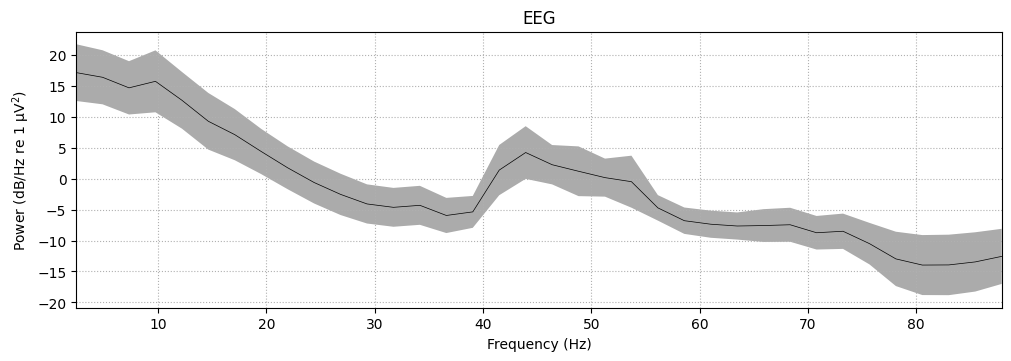

In [53]:
raw.plot_psd(fmin=2, fmax=90, average=True);  # Before

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 0.410 (s)
Plotting power spectral density (dB=True).


c:\Users\np3106\Projects\Sleep_Scoring\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


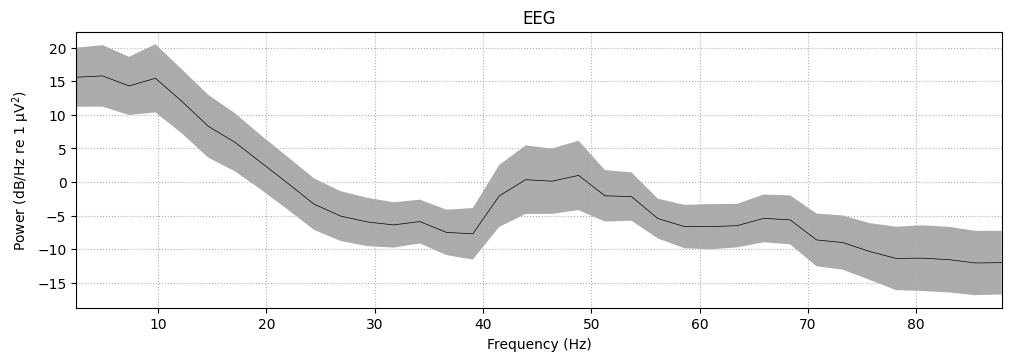

In [54]:
raw_clean.plot_psd(fmin=2, fmax=90, average=True);  # After

In [58]:
import mne
from mne.preprocessing import ICA

mne.viz.set_browser_backend("qt")

vhdr = "H042/042_scan.vhdr"
raw = mne.io.read_raw_brainvision(vhdr, preload=True, verbose=False)

raw.set_channel_types({
    "EOG1": "eog",
    "EOG2": "eog",
    "ECG": "ecg",
    "EMG1": "emg",
    "EMG2": "emg",
    "EMG3": "emg",
    "M1": "misc",
    "M2": "misc",
})

raw.resample(256)

raw_segment = raw.copy().crop(tmin=1020.491, tmax=1180.412)

# Optional but often recommended for scalp EEG:
raw_segment.set_eeg_reference("average", projection=False)

# Filtered copy for ICA fitting
raw_ica = raw_segment.copy().filter(l_freq=1.0, h_freq=None, fir_design="firwin")



C:\Users\np3106\AppData\Local\Temp\ipykernel_16124\3507774889.py:7: RuntimeWarning: No coordinate information found for channels ['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw = mne.io.read_raw_brainvision(vhdr, preload=True, verbose=False)
C:\Users\np3106\AppData\Local\Temp\ipykernel_16124\3507774889.py:7: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision(vhdr, preload=True, verbose=False)
C:\Users\np3106\AppData\Local\Temp\ipykernel_16124\3507774889.py:9: RuntimeWarning: The unit for channel(s) ECG, EMG1, EMG2, EMG3 has changed from NA to V.
  raw.set_channel_types({


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 845 samples (3.301 s)



NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


c:\Users\np3106\Projects\Sleep_Scoring\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


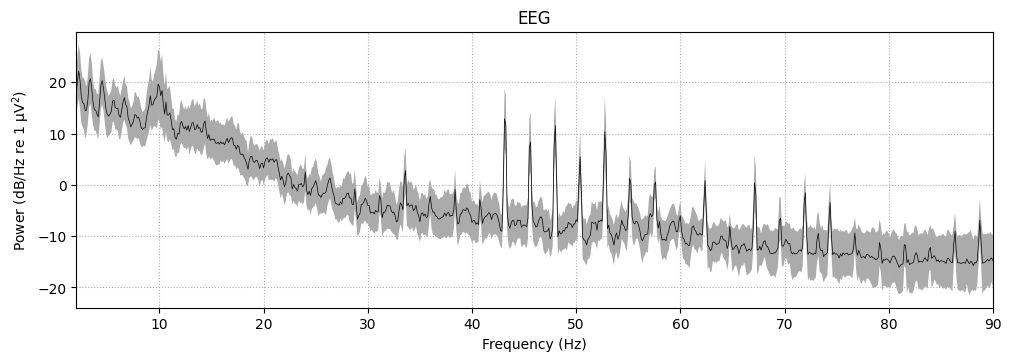

In [59]:
raw_segment.plot_psd(fmin=2, fmax=90, average=True)       # Original (Common Reference)

In [60]:

# Fit ICA on EEG channels only (recommended)
picks_eeg = mne.pick_types(raw_ica.info, eeg=True, eog=False, ecg=False, emg=False, misc=False)

ica = ICA(n_components=0.99, method="fastica", random_state=97)
ica.fit(raw_ica, picks=picks_eeg)

# Detect ECG/EOG-related ICs on the *unfiltered* segment
ecg_idx, ecg_scores = ica.find_bads_ecg(raw_segment, ch_name="ECG")

eog_idx1, eog_scores1 = ica.find_bads_eog(raw_segment, ch_name="EOG1")
eog_idx2, eog_scores2 = ica.find_bads_eog(raw_segment, ch_name="EOG2")
eog_idx = list(set(eog_idx1 + eog_idx2))

ica.exclude = [6]#list(set(ecg_idx + eog_idx))

print("Excluding components:", ica.exclude)

Fitting ICA to data using 24 channels (please be patient, this may take a while)
Selecting by explained variance: 9 components
Fitting ICA took 0.4s.
Using threshold: 0.32 for CTPS ECG detection
Using channel ECG to identify heart beats.
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 2560 samples (10.000 s)

Number of ECG events detected : 207 (average pulse 77.6629213483146 / min.)
Not setting metadata
207 matching events found
No baseline correction applied
Using data from preloaded Raw for 207 events and 257 original time points ...
1 bad epochs dropped
Using EOG channel: EOG1


    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
79 matching events found
No baseline correction applied
0 projection items activated


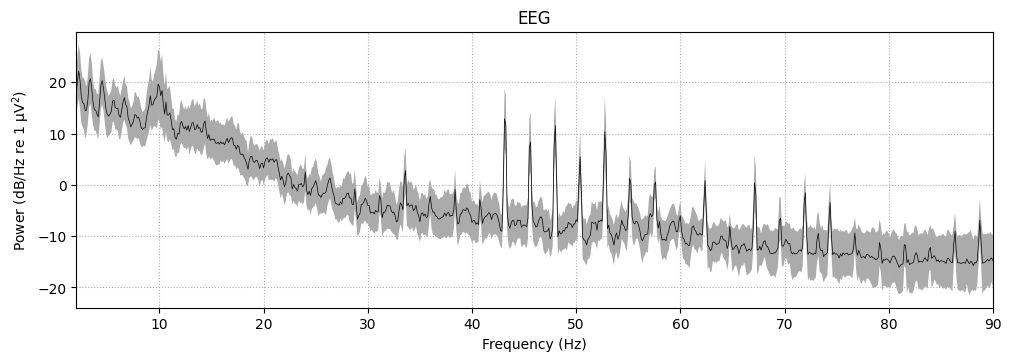

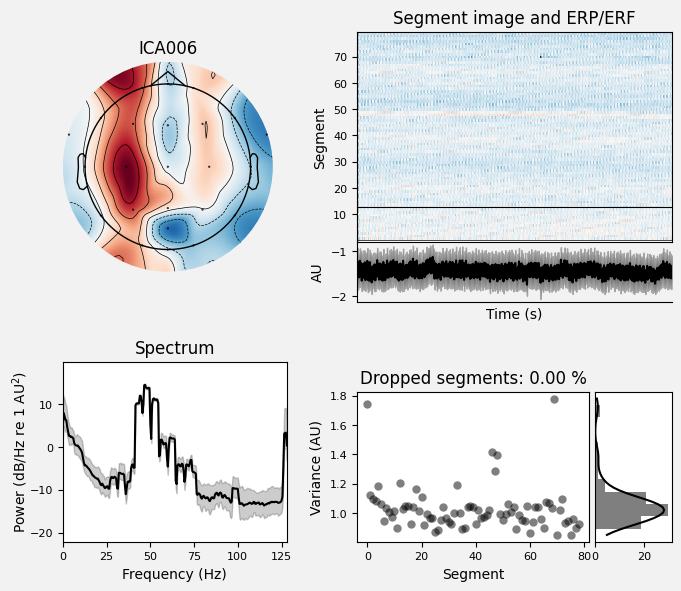

[<Figure size 700x600 with 6 Axes>]

In [61]:
ica.plot_properties(raw_segment, picks=ica.exclude)

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


c:\Users\np3106\Projects\Sleep_Scoring\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


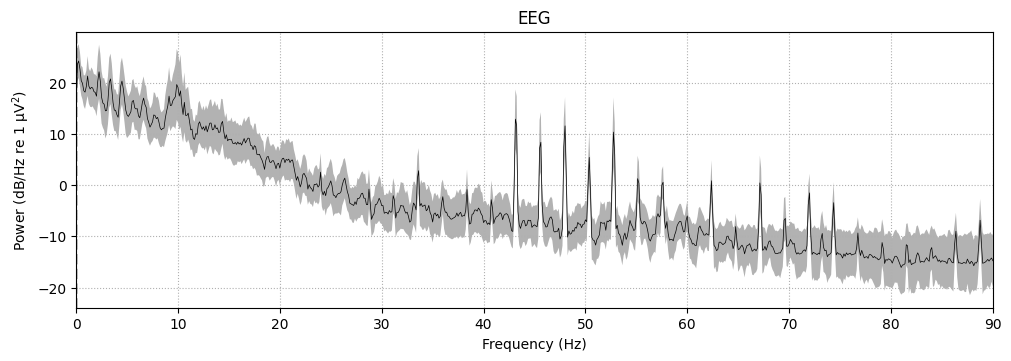

In [62]:
raw_segment.compute_psd(fmax=90).plot(picks="eeg", average=True)   # Before

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


c:\Users\np3106\Projects\Sleep_Scoring\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


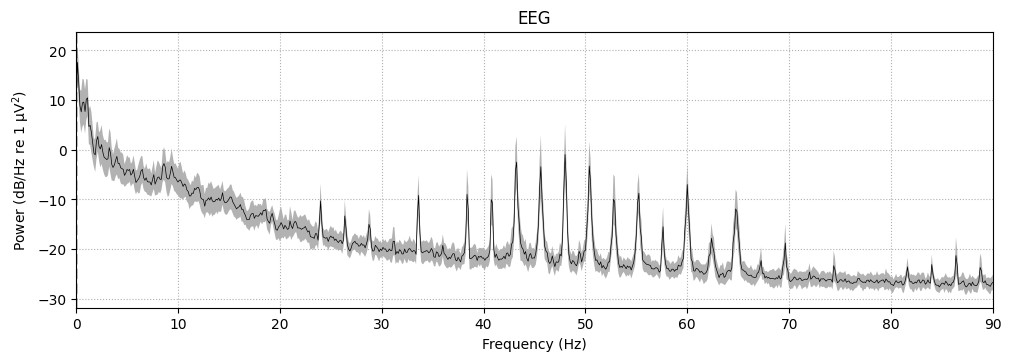

In [63]:
raw_cleaned.compute_psd(fmax=90).plot(picks="eeg", average=True)   # After

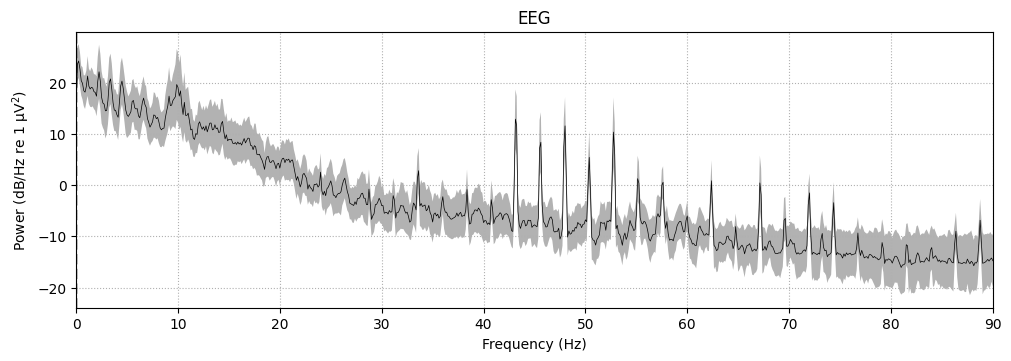

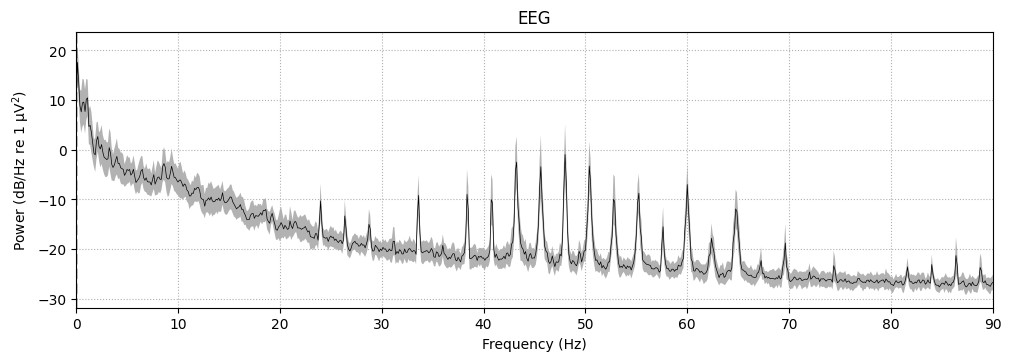

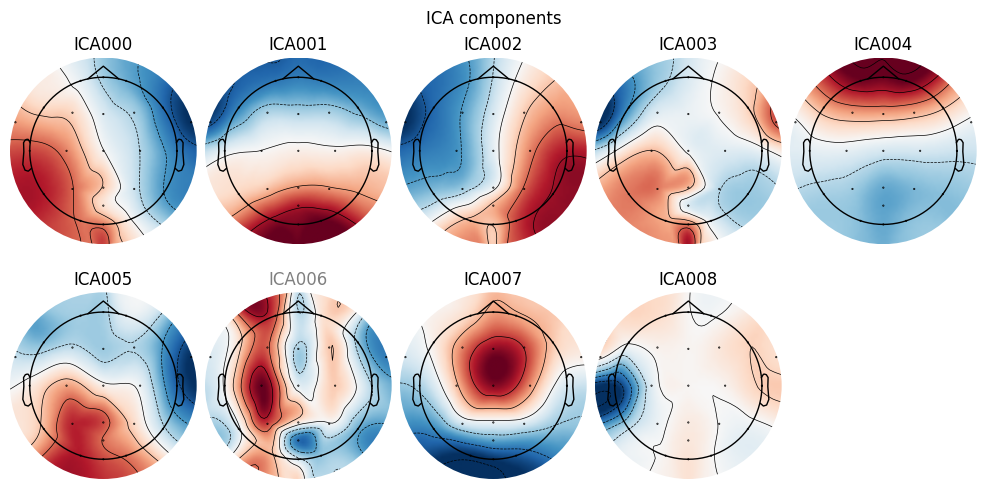

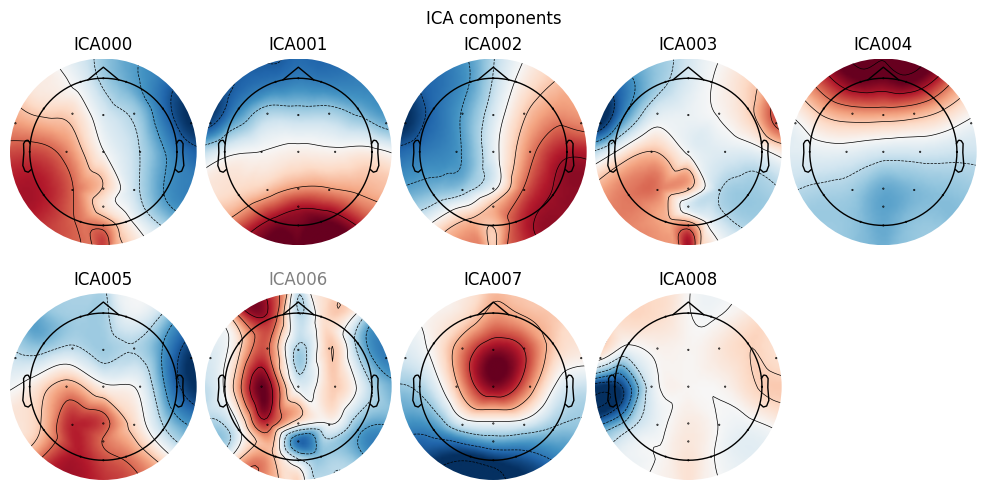

In [64]:
ica.plot_components()

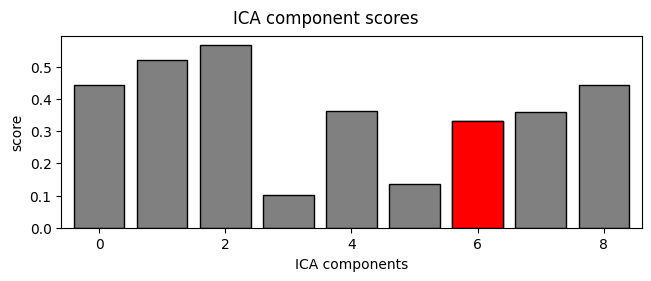

In [65]:
ica.plot_scores(ecg_scores);

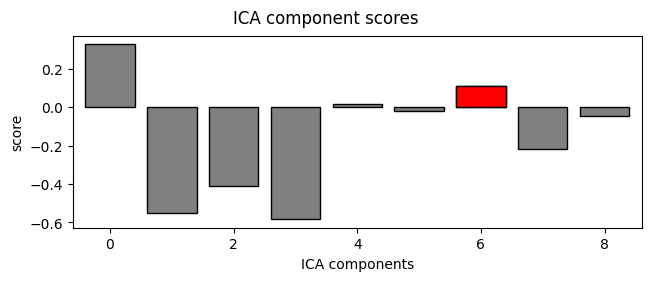

In [66]:
ica.plot_scores(eog_scores1);

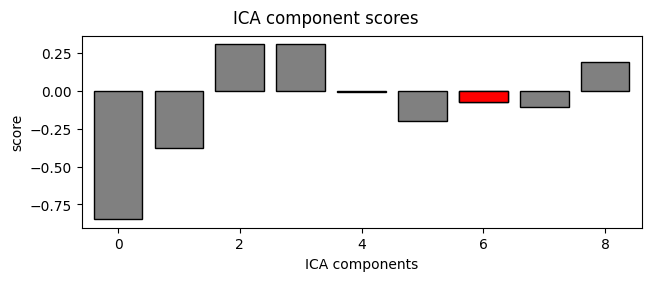

In [67]:
ica.plot_scores(eog_scores2);